In [1]:
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage,AIMessage,HumanMessage
from langgraph.checkpoint.sqlite import SqliteSaver
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langgraph.prebuilt import tools_condition,ToolNode
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
import sqlite3
import requests
import os

e:\LangGraph\myenv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
load_dotenv(dotenv_path=".env", override=True)
GROQ_API_KEY = os.getenv('GROQ_API_KEY')
llm= ChatGroq(
    model="llama-3.3-70b-versatile",  
    api_key=GROQ_API_KEY  
)

In [4]:
search_tool=DuckDuckGoSearchRun(region="us-en")

In [5]:
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}




@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [6]:
tools=[search_tool,get_stock_price,calculator]

llm_with_tools=llm.bind_tools(tools)

In [7]:
class chatstate(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]
    

In [29]:
graph=StateGraph(chatstate)
def msg_node(state:chatstate):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

In [30]:
conn = sqlite3.connect(database="chatbot.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

In [31]:
graph.add_node('msg_node',msg_node)
graph.add_node("tools", tool_node)
graph.add_edge(START,'msg_node')
graph.add_conditional_edges('msg_node',tools_condition)
graph.add_edge('tools','msg_node')
graph.add_edge('msg_node',END)

In [32]:
chatbot=graph.compile(checkpointer=checkpointer)

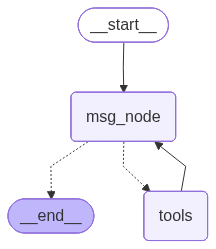

In [33]:
chatbot